In [210]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers
import EvalHelpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler

import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib


#### Need to show 
* Neural networks beat baselines (more trustworthy than logistic regression or random chance) - in this notebook
* Neural networks predict some consistent emergence time that is earlier than logistic regression - in this notebook
* Predictions hold in observations - in the ObsPredict.ipynb notebook

In [211]:
ssplist = ["126","245","370","585"]
ssplistplot = ["hist"]+ ssplist 

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
ntrain = 25
nval = 13
test = np.arange(38,50)
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1960,2025]
baselineera_obs = [1940,1960]

inputlength = 10
outputavgtime = 10
# data params
outres = 5
timerange = [1900,2100]
filefront = "MPI_"
# modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

analysisparams = {
    "experiment_era":experiment_era,
    "baselineera":baselineera,
    "trainvaltest":trainvaltest,
    "ssps":ssplist,
    "inputlength":inputlength,
    "outputavgtime":outputavgtime,
    "experiment_era_obs":experiment_era_obs,
    "baselineera_obs":baselineera_obs,
}

sspkeep = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)
AllObs = DataHolder.ERA5InputOutput(params)

latvec = AllData.output_lat
lonvec = AllData.output_lon



data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


### Logistic Regression

In [212]:
imp.reload(EvalHelpers)

ModelEvals = EvalHelpers.HistoricMax(analysisparams)

In [213]:
lr_accuracy, lr_brierscore, lr_first_correct = ModelEvals.logistic_regression(AllData,sspkeep)

baseline for temp records is 0 50 (not used)
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
-90
-80
-70
-60
-50
-40
-30
-20
-10
0
baseline for temp records is 0 50 (not used)
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
10
20
30
40
50
60
70
80


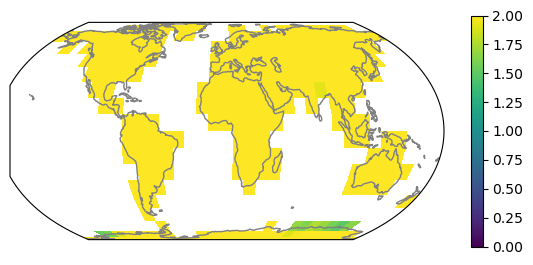

In [214]:
plt.figure(figsize=(7,3))
ax = plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,ModelEvals.lr_coeffs,transform=ccrs.PlateCarree(),vmin=0,vmax=2)
ax.coastlines(color='gray')
plt.colorbar(c1)

### CNN evals

In [215]:
cnn_accuracy, cnn_brierscore, cnn_first_correct = ModelEvals.cnn_evaluation(AllData)

baseline for temp records is 0 50 (not used)
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


### Show difference between CNN and logistic regression

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/325643954.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


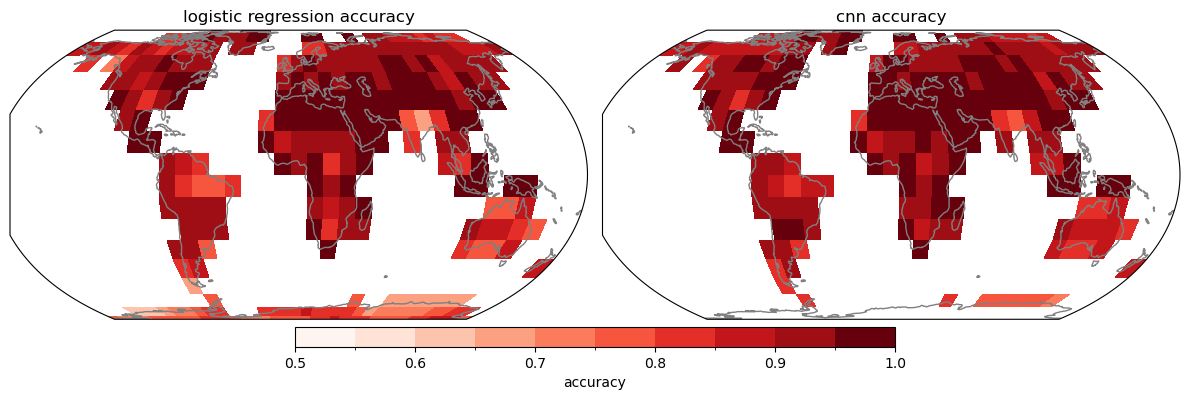

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/325643954.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


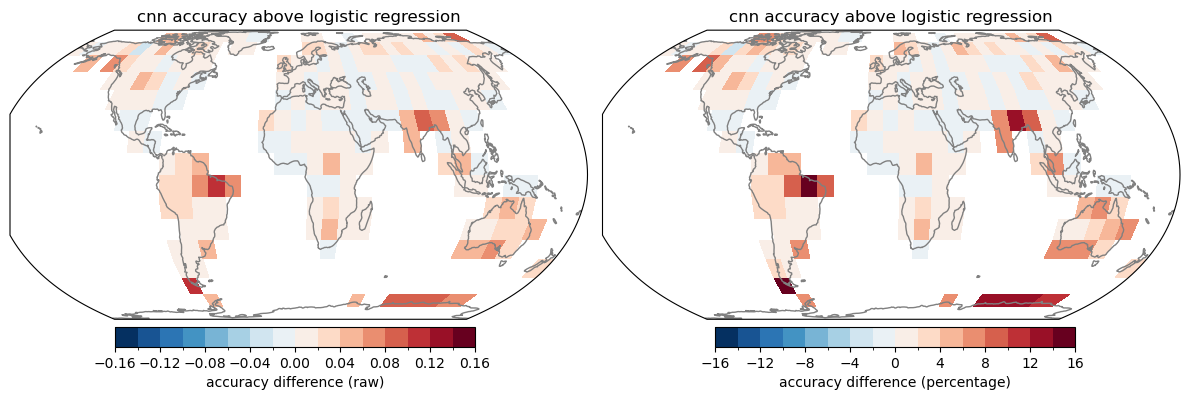

In [216]:
levsacc = np.linspace(0.5,1,11)
cmapacc = plt.get_cmap("Reds")

normacc = BoundaryNorm(levsacc,cmapacc.N)

diff1 = np.linspace(-0.16,0.16,17)
cmapdiff1 = plt.get_cmap("RdBu_r")
normdiff = BoundaryNorm(diff1,cmapdiff1.N)

diffper = np.linspace(-16,16,17)
cmapdiffper = plt.get_cmap("RdBu_r")
normdiffper = BoundaryNorm(diffper,cmapdiffper.N)

plt.figure(figsize=(12,4))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,lr_accuracy[:,:,0],norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression accuracy')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,cnn_accuracy[:,:,0],norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

cax = plt.axes((0.25,0.07,0.5,0.05))
cbar1 = plt.colorbar(c1,cax,orientation='horizontal')
cbar1.ax.set_xlabel('accuracy')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))

a1=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
c2=a1.pcolormesh(lonvec+5,latvec+5,cnn_accuracy[:,:,0]-lr_accuracy[:,:,0],norm=normdiff,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
c3=a1.pcolormesh(lonvec+5,latvec+5,100*(cnn_accuracy[:,:,0]-lr_accuracy[:,:,0])/lr_accuracy[:,:,0],norm=normdiffper,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

cax2 = plt.axes((0.1,0.07,0.3,0.05))
cbar2 = plt.colorbar(c2,cax2,orientation='horizontal',ticks=np.arange(-0.16,0.2,0.04))
cbar2.ax.set_xlabel('accuracy difference (raw)')

cax3 = plt.axes((0.6,0.07,0.3,0.05))
cbar3 = plt.colorbar(c3,cax3,orientation='horizontal',ticks=np.arange(-16,20,4))
cbar3.ax.set_xlabel('accuracy difference (percentage)')

plt.tight_layout()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/4214122122.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


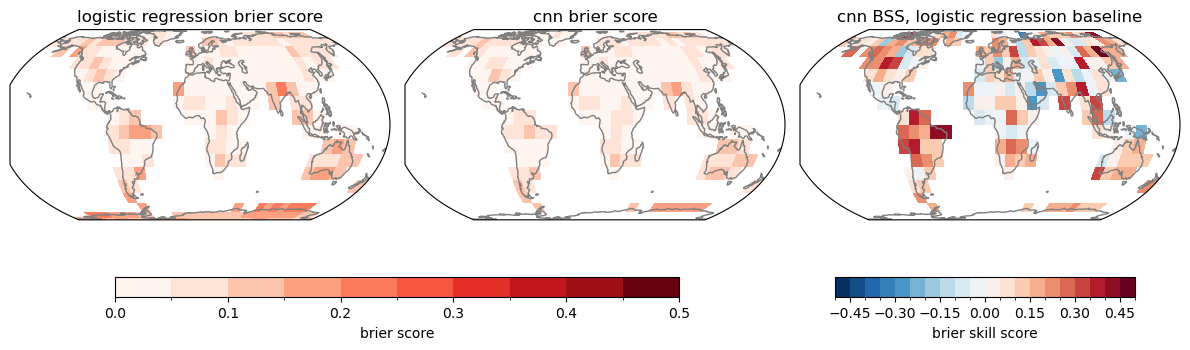

In [217]:
bss = 1-(cnn_brierscore/lr_brierscore)

levsbs = np.linspace(0,0.5,11)
cmapbs = plt.get_cmap("Reds")

normbs = BoundaryNorm(levsbs,cmapbs.N)

diffbss = np.linspace(-0.5,0.5,21)
cmapdiffbss = plt.get_cmap("RdBu_r")
normbss = BoundaryNorm(diffbss,cmapdiffbss.N)

plt.figure(figsize=(12,4))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,lr_brierscore,norm=normbs,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression brier score')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,cnn_brierscore,norm=normbs,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn brier score')

cax = plt.axes((0.1,0.07,0.47,0.05))
cbar1 = plt.colorbar(c1,cax,orientation='horizontal')
cbar1.ax.set_xlabel('brier score')


a1=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
c2=a1.pcolormesh(lonvec+5,latvec+5,bss,norm=normbss,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn BSS, logistic regression baseline')

# a1=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
# c3=a1.pcolormesh(lonvec+5,latvec+5,100*(bestaccs[:,:,0]-lr_accuracy_all[:,:,0])/lr_accuracy_all[:,:,0],norm=normdiffper,cmap='RdBu_r',transform=ccrs.PlateCarree())
# a1.coastlines(color='gray')
# plt.title('cnn accuracy above logistic regression')

cax2 = plt.axes((0.7,0.07,0.25,0.05))
cbar2 = plt.colorbar(c2,cax2,orientation='horizontal')
cbar2.ax.set_xlabel('brier skill score')

# cax3 = plt.axes((0.6,0.07,0.3,0.05))
# cbar3 = plt.colorbar(c3,cax3,orientation='horizontal',ticks=np.arange(-16,20,4))
# cbar3.ax.set_xlabel('accuracy difference (percentage)')

plt.tight_layout()
plt.show()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/307105597.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


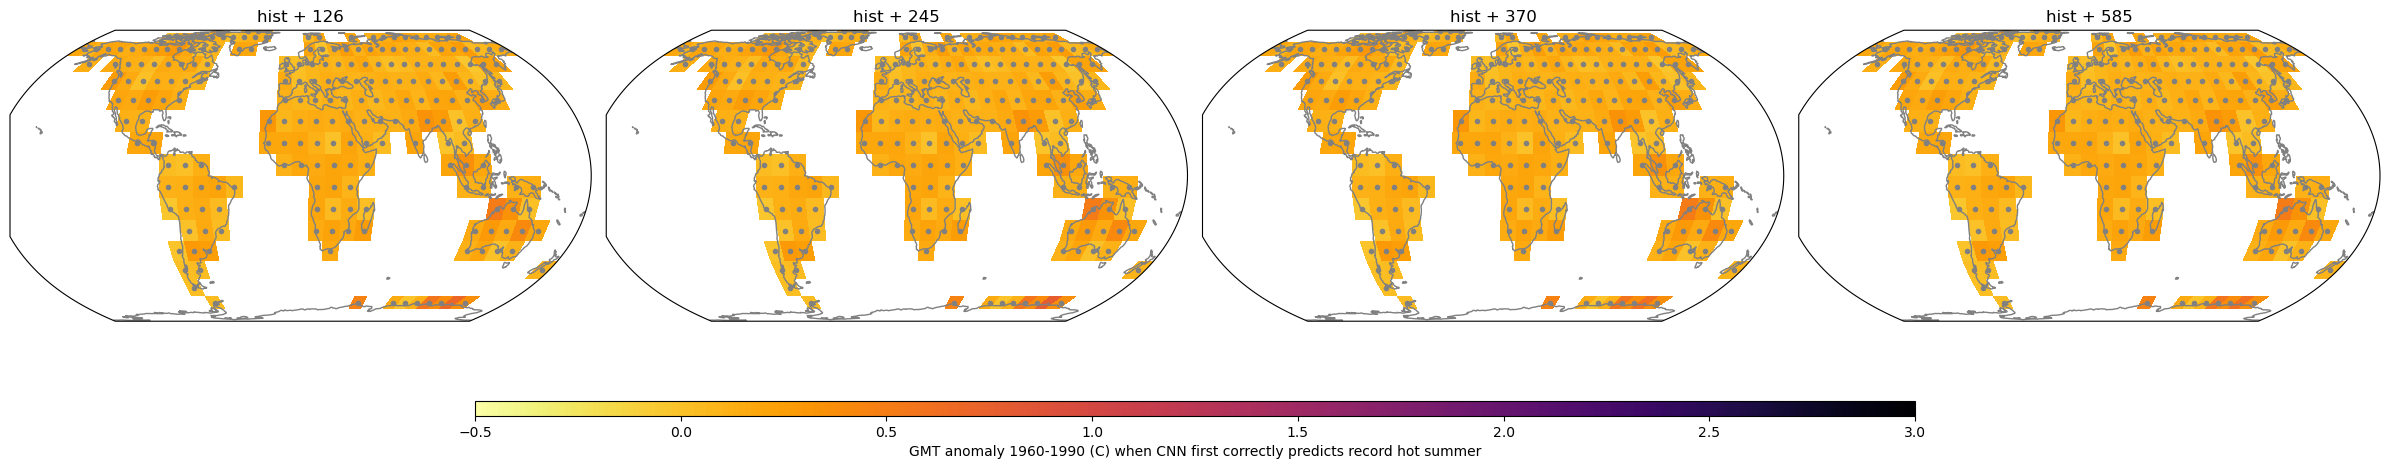

In [218]:
plt.figure(figsize=(24,5))

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

for iplot in range(4):

    gmt_first_correct_plop = np.concatenate((cnn_first_correct[[0]],cnn_first_correct[[iplot+1]]),axis=0)
    gmt_first_correct_plot = np.nanmin(gmt_first_correct_plop,axis=0)

    histmask = ~np.isnan(cnn_first_correct[0])
    lonhist = lonmesh[histmask]
    lathist = latmesh[histmask]

    ax=plt.subplot(1,4,iplot+1,projection=ccrs.EqualEarth())
    c1=ax.pcolormesh(lonvec+5,latvec+5,gmt_first_correct_plot,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
    ax.scatter(lonhist,lathist,color='gray',marker='.',transform=ccrs.PlateCarree())
    plt.title("hist + " +ssplistplot[iplot+1])
    ax.coastlines(color='gray')

all_first_correct = np.nanmin(cnn_first_correct,axis=0)

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly 1960-1990 (C) when CNN first correctly predicts record hot summer')

plt.tight_layout()
plt.show()


/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/3696704610.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


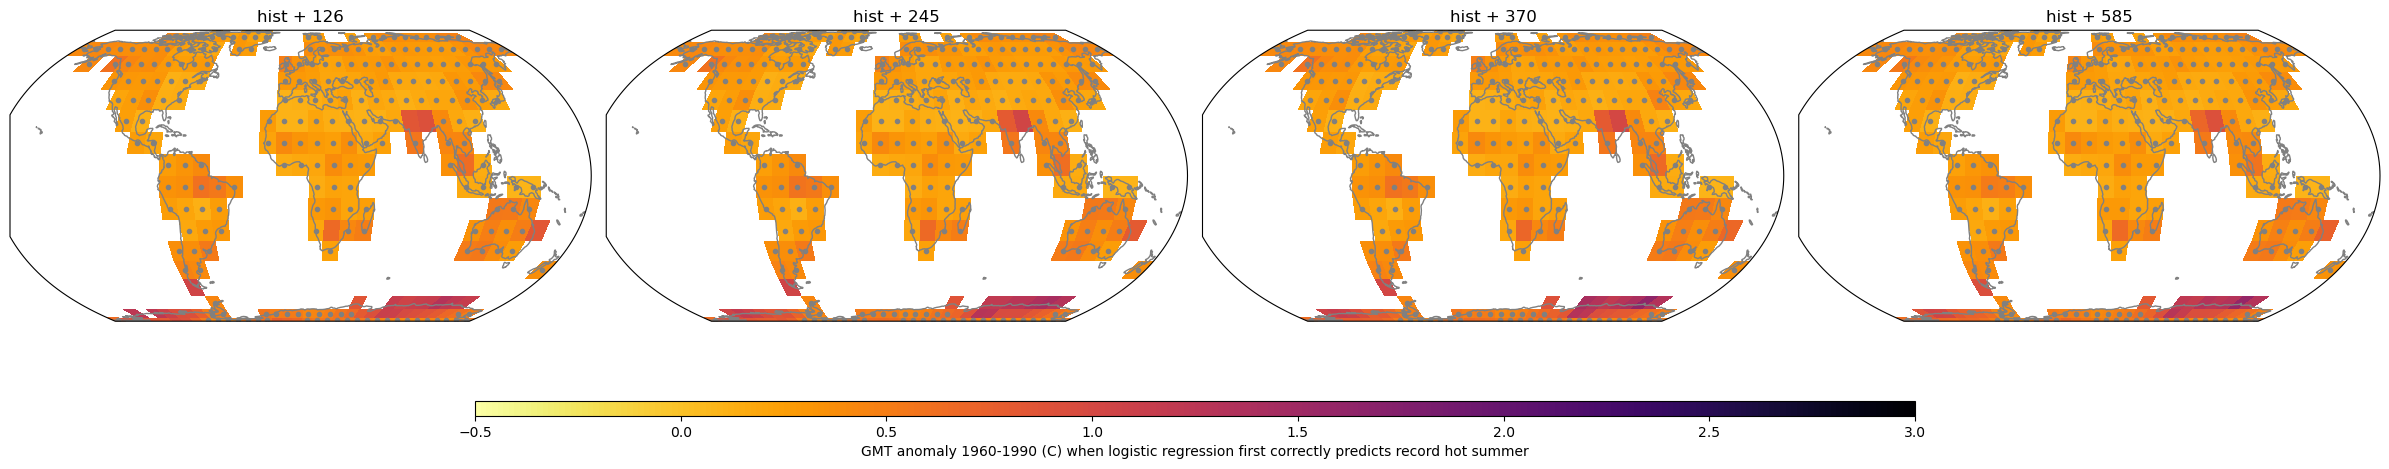

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/3696704610.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


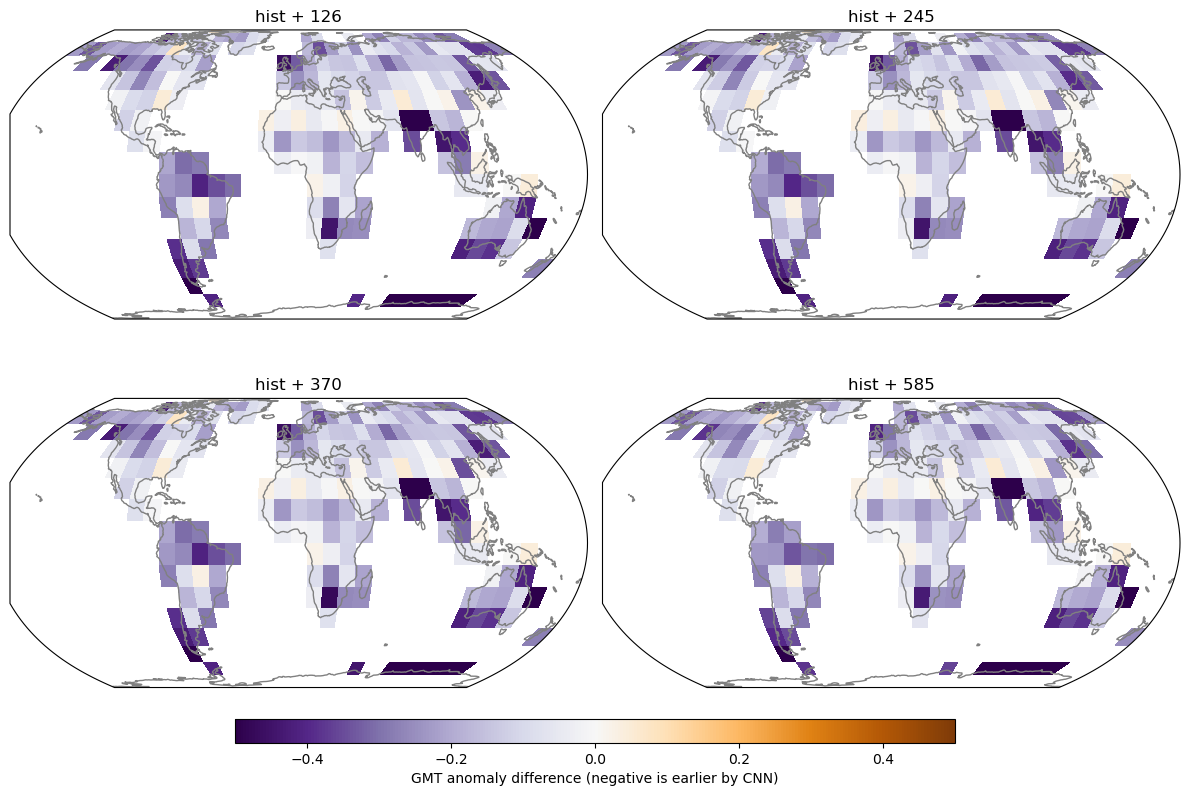

In [219]:
plt.figure(figsize=(24,5))

for iplot in range(4):

    histmask = ~np.isnan(lr_first_correct[0])
    lonhist = lonmesh[histmask]
    lathist = latmesh[histmask]

    lr_first_correct_plop = np.concatenate((lr_first_correct[[0]],lr_first_correct[[iplot+1]]),axis=0)
    lr_first_correct_plot = np.nanmin(lr_first_correct_plop,axis=0)

    ax=plt.subplot(1,4,iplot+1,projection=ccrs.EqualEarth())
    c2=ax.pcolormesh(lonvec+5,latvec+5,lr_first_correct_plot,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
    ax.scatter(lonhist,lathist,color='gray',marker='.',transform=ccrs.PlateCarree())
    plt.title("hist + "+ssplist[iplot])
    ax.coastlines(color='gray')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c2,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly 1960-1990 (C) when logistic regression first correctly predicts record hot summer')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12,8))

for iplot in range(4):

    gmt_first_correct_plop = np.concatenate((cnn_first_correct[[0]],cnn_first_correct[[iplot+1]]),axis=0)
    gmt_first_correct_plot = np.nanmin(gmt_first_correct_plop,axis=0)

    lr_first_correct_plop = np.concatenate((lr_first_correct[[0]],lr_first_correct[[iplot+1]]),axis=0)
    lr_first_correct_plot = np.nanmin(lr_first_correct_plop,axis=0)

    ax=plt.subplot(2,2,iplot+1,projection=ccrs.EqualEarth())
    c2=ax.pcolormesh(lonvec+5,latvec+5,gmt_first_correct_plot-lr_first_correct_plot,vmin=-0.5,vmax=0.5,cmap='PuOr_r',transform=ccrs.PlateCarree())
    # ax.scatter(lonhist,lathist,color='gray',marker='.',transform=ccrs.PlateCarree())
    plt.title("hist + " +ssplistplot[iplot+1])
    ax.coastlines(color='gray')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c2,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly difference (negative is earlier by CNN)')

plt.tight_layout()
plt.show()

In [220]:
# preds = ModelEvals.cnnpred
# inputGMT = ModelEvals.inputGMTtest
# inputssp = ModelEvals.inputssptest.squeeze()

In [221]:
# sspvals = [-0.2,-0.1,0,0.1,0.2]
# color=['grey','blue','green','orange','red']

# for issp,sspval in enumerate(sspvals):
#     plt.scatter(inputGMT[inputssp==sspval],np.mean(preds,axis=0)[inputssp==sspval],color=color[issp],alpha=0.6)

In [222]:
# imp.reload(DataHolder)

# outputavgtime = 10

# analysisparams = {
#     "experiment_era":experiment_era,
#     "baselineera":baselineera,
#     "trainvaltest":trainvaltest,
#     "ssps":ssplist,
#     "inputlength":inputlength,
#     "outputavgtime":outputavgtime,
#     "experiment_era_obs":experiment_era_obs,
#     "baselineera_obs":baselineera_obs,
# }

# imp.reload(EvalHelpers)

# ModelEvals = EvalHelpers.HistoricMax(analysisparams)
cnn_obs_evals,lr_obs_evals = ModelEvals.obs_evaluation(AllObs)

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/1361169277.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


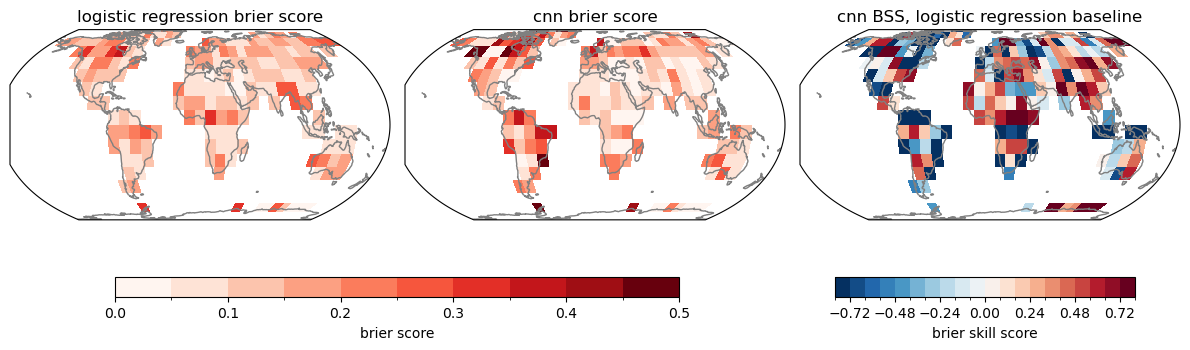

In [223]:
bss = 1-(cnn_brierscore/lr_brierscore)

levsbs = np.linspace(0,0.5,11)
cmapbs = plt.get_cmap("Reds")

normbs = BoundaryNorm(levsbs,cmapbs.N)

diffbss = np.linspace(-0.8,0.8,21)
cmapdiffbss = plt.get_cmap("RdBu_r")
normbss = BoundaryNorm(diffbss,cmapdiffbss.N)

plt.figure(figsize=(12,4))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,lr_obs_evals[1],norm=normbs,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression brier score')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,cnn_obs_evals[1],norm=normbs,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn brier score')

cax = plt.axes((0.1,0.07,0.47,0.05))
cbar1 = plt.colorbar(c1,cax,orientation='horizontal')
cbar1.ax.set_xlabel('brier score')

bss_obs = 1-(cnn_obs_evals[1]/lr_obs_evals[1])

a1=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
c2=a1.pcolormesh(lonvec+5,latvec+5,bss_obs,norm=normbss,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn BSS, logistic regression baseline')

cax2 = plt.axes((0.7,0.07,0.25,0.05))
cbar2 = plt.colorbar(c2,cax2,orientation='horizontal')
cbar2.ax.set_xlabel('brier skill score')

plt.tight_layout()
plt.show()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_43788/1673064189.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


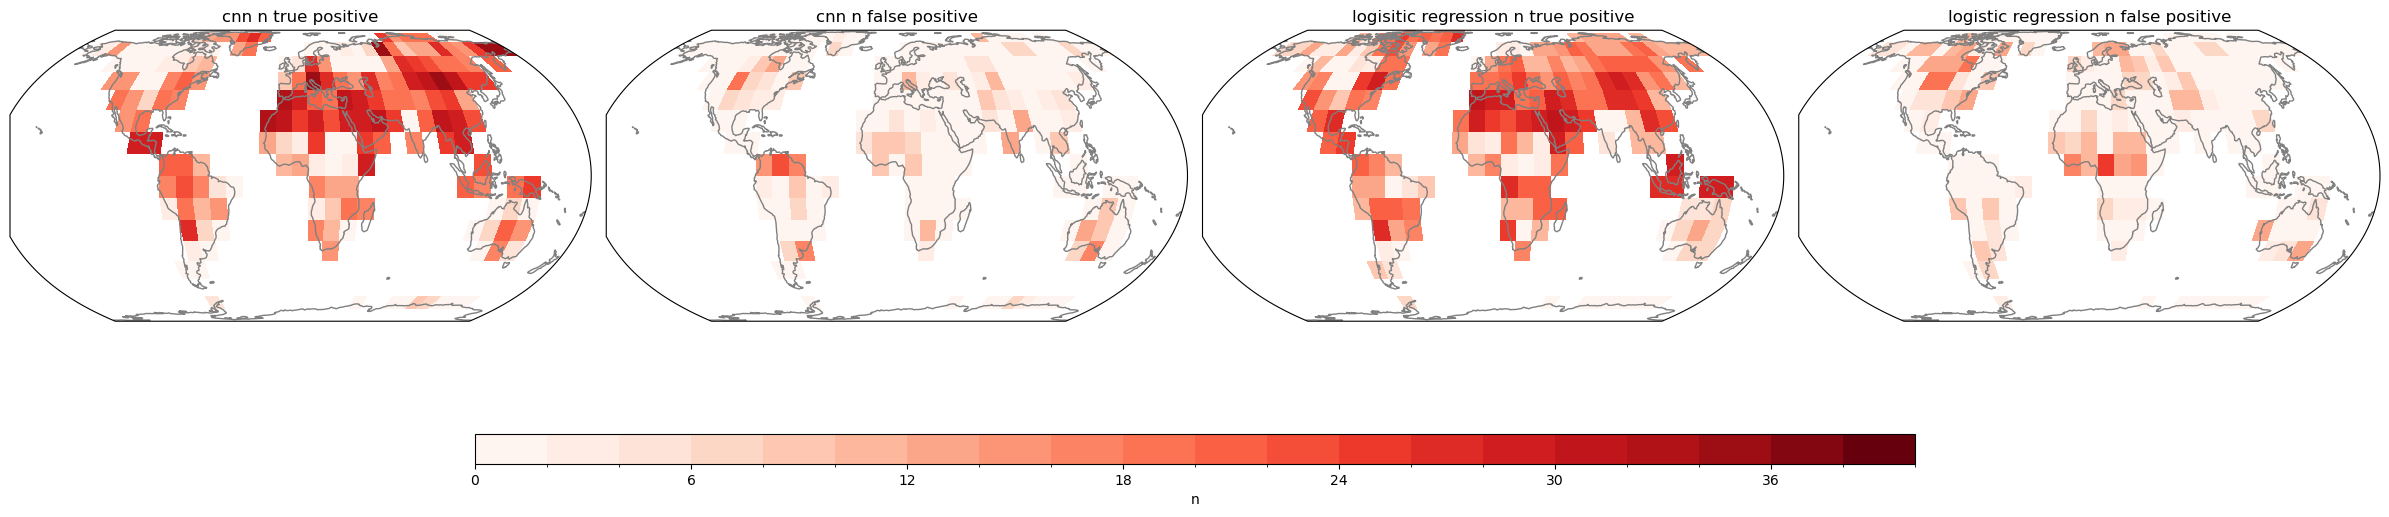

In [224]:
levstpr = np.linspace(0,40,21)
cmaptpr = plt.get_cmap("Reds")
normtpr = BoundaryNorm(levstpr,cmaptpr.N)

plt.figure(figsize=(24,6))

a1=plt.subplot(1,4,1,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,ModelEvals.cnn_tp,norm=normtpr,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn n true positive')

a1=plt.subplot(1,4,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,ModelEvals.cnn_fp,norm=normtpr,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn n false positive')

a1=plt.subplot(1,4,3,projection=ccrs.EqualEarth())
c1=a1.pcolormesh(lonvec+5,latvec+5,ModelEvals.lr_tp,norm=normtpr,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logisitic regression n true positive')

a1=plt.subplot(1,4,4,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,ModelEvals.lr_fp,norm=normtpr,cmap='Reds',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression n false positive')

cax = plt.axes((0.2,0.02,0.6,0.05))
cbar1 = plt.colorbar(c1,cax,orientation='horizontal')
cbar1.ax.set_xlabel('n')

plt.tight_layout()
plt.show()

In [225]:
# imp.reload(EvalHelpers)

latsel = 40
lonsel = 240
# #
# ModelEvals = EvalHelpers.HistoricMax(analysisparams)
ModelEvals.GridPointSel(AllData,latsel,lonsel)

preds = ModelEvals.cnnpred
inputGMT = ModelEvals.inputGMTtest
inputssp = ModelEvals.inputssptest.squeeze()

lrmodel = ModelEvals.lrmodel

baseline for temp records is 0 50 (not used)
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


In [226]:
lrmodel.coef_

array([[5.95588361]])